In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from helpers import load_config

In [7]:
# Parameters
country = "NZL" #["NZL", "ninty", "all", "ninty2022"]
#country = snakemake.wildcards.country
plt_arrows = True

PREFIX = "/mnt/c/Users/scl38887/Documents/git/pypsa-nz/"
tech_colors = PREFIX + "config/tech_colors.yaml"

Info: MBIE also states 88% in source: mbieelectricity2024

### Load config

In [8]:
colors = load_config(tech_colors)["paper_colors"]

### Get shares

In [9]:
# reshare = pd.read_csv('../../data/owid/share-of-electricity-production-from-renewable-sources.csv')
reshare = pd.read_csv(snakemake.input.reshares)

In [10]:
reshare = reshare.dropna(subset=['Code'])
reshare = reshare.rename(columns={'Renewables - % electricity': 'reshare'})

In [11]:
if country == "ninty":
    country_ninty = reshare.loc[reshare['reshare'] >= 90].Code.unique()
    country_ninty = country_ninty
    reshare = reshare[reshare.Code.isin(country_ninty)]

elif country == "ninty2022":
    country_ninty = reshare[(reshare.Year == 2022) & (reshare.reshare >= 90)].Code.unique()
    country_ninty = country_ninty
    reshare = reshare[reshare.Code.isin(country_ninty)]

elif country == "all":
    reshare = reshare
else:
    reshare = reshare[reshare.Code == country]

### Plot

In [12]:
reshare = reshare.set_index('Year')

NameError: name 'snakemake' is not defined

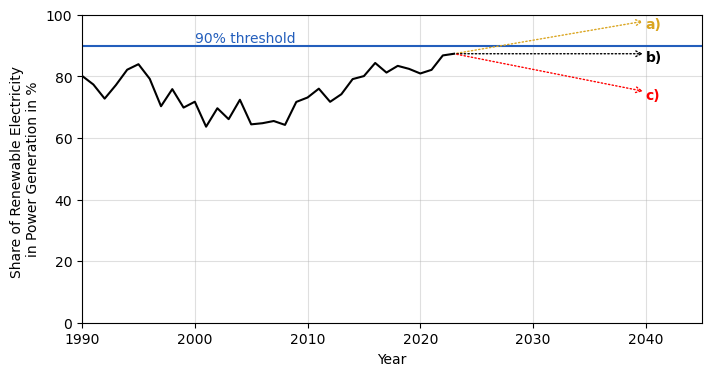

In [15]:
# Set up figure
fig = plt.figure(facecolor='white', figsize=(8, 4))

ax = fig.add_subplot(1,1,1)

for code in reshare.Code.unique():
    ax.plot("reshare", data=reshare[reshare.Code == code] , color="black")

# Add a vertical line at 90% and label it "90% threshold"
plt.axhline(y=90, color=colors["threshold"], linestyle='-')
plt.text(2000, 91, '90% threshold', color=colors["threshold"])

# Add dotted arrows
if plt_arrows==True:
    end_x, end_y = reshare[reshare.Code == code].index[-1], reshare[reshare.Code == code].reshare.values[-1]
    target_x = {"a": 2040, "b": 2040, "c": 2040}
    target_y = {"a": 98, "b": end_y, "c": 75}
    # text = {"a": "a) RE > demand+\nexport", "b": "b) RE = demand+\nexport", "c": "c) RE < demand+\nexport"}
    text = {"a": "a)", "b": "b)", "c": "c)"}
    color = {"a": colors["case_a"], "b": colors["case_b"], "c": colors["case_c"]}
    scenario_data = {}
    scenarios = ["a", "b", "c"]

    for sc in scenarios:
        plt.annotate('', xy=(target_x[sc], target_y[sc]), xytext=(end_x, end_y),
                    arrowprops=dict(arrowstyle='->', linestyle=':', color=color[sc]))

        plt.text(target_x[sc], target_y[sc]-1,                   # Coordinates for the label
                    text[sc],                    # Text to display
                    fontsize=10,                    # Font size of the label
                    color=color[sc],                   # Font color
                    ha='left',                     # Horizontal alignment
                    va='center',                     # Vertical alignment
                    weight='bold')

# Limit the plot
ax.set_xlim(1990, 2045)
ax.set_ylim(0,100)

# Further elements
ax.set_ylabel("Share of Renewable Electricity \nin Power Generation in %")
ax.set_xlabel("Year")
plt.grid(alpha=0.4)

# Create graph and save it
fig.savefig(snakemake.output.reshares, bbox_inches="tight")
fig.savefig(snakemake.output.reshares_png, bbox_inches="tight", dpi=300)

plt.show()